In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import pickle

# Loading Dataset

In [3]:
df = pd.read_csv("/home/aryan/Desktop/Smart-Agriculture-Prediction-Platform/datasets/Crop_recommendation.csv")

In [4]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [7]:
df.tail()



,N,P,K,temperature,humidity,ph,rainfall,label
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee
2199,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee


In [5]:
df.shape

(2200, 8)

# EDA

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


# conclusion : 

NPK are of int type

temperature humidity and ph are of float type

Label is of object Datatype so there is need of encoding 



In [8]:
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

# Conclusion : 

there are no missing values so no need of handling missing values

In [9]:
df.duplicated().sum()

np.int64(0)

# Conclusion : 

there are no Duplicate values so no need of handling Duplicate values

In [10]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [11]:
#conclusion : seeing values statistics , there is need of feature scaling

In [12]:
df["label"].value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

# conclusion: 

class is balanced


In [15]:
df["label"].nunique()

22

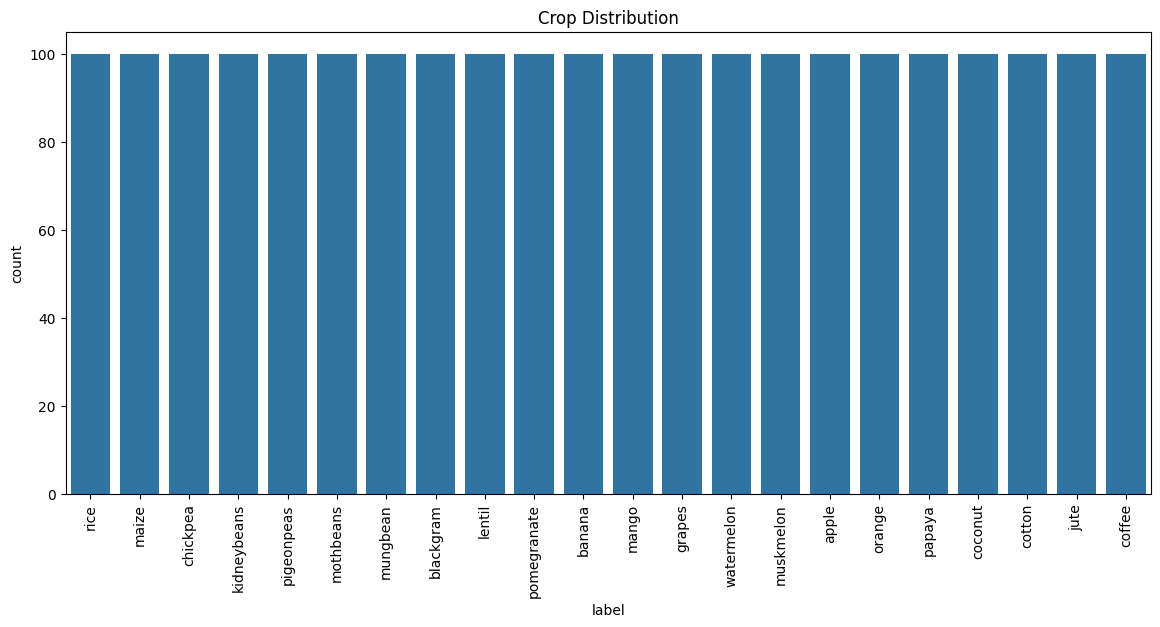

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))
sns.countplot(x="label", data=df)
plt.xticks(rotation=90)
plt.title("Crop Distribution")
plt.show()

# Doing Univariate Analysis

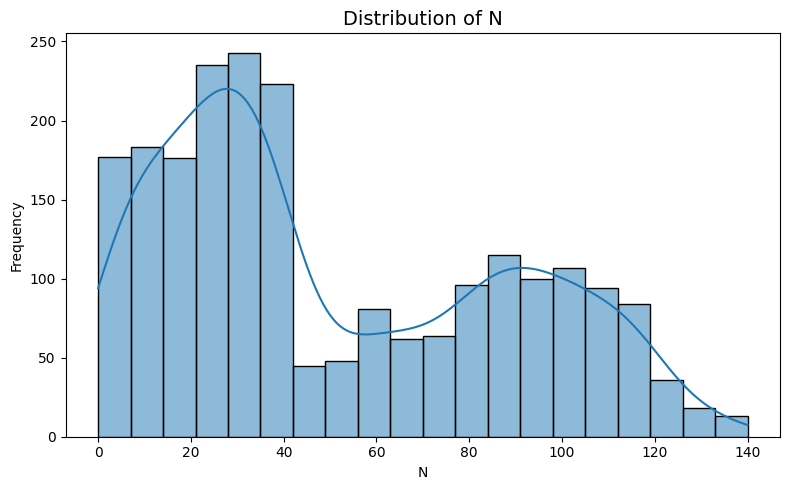


--------------------------------------------------------------------------------



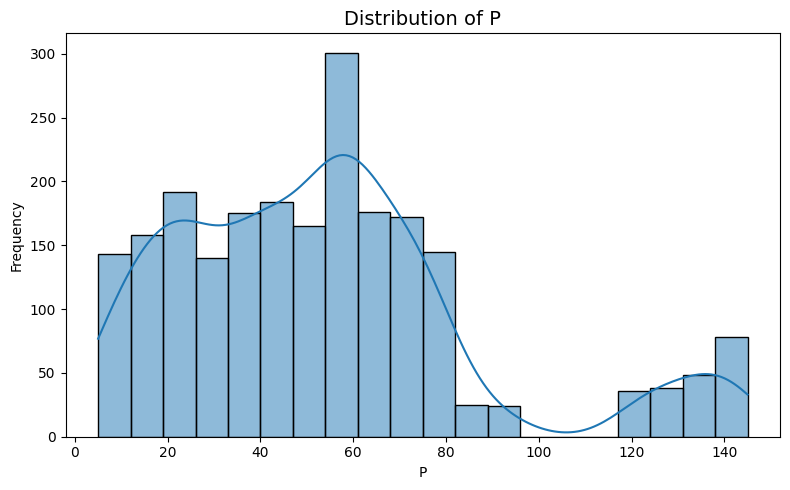


--------------------------------------------------------------------------------



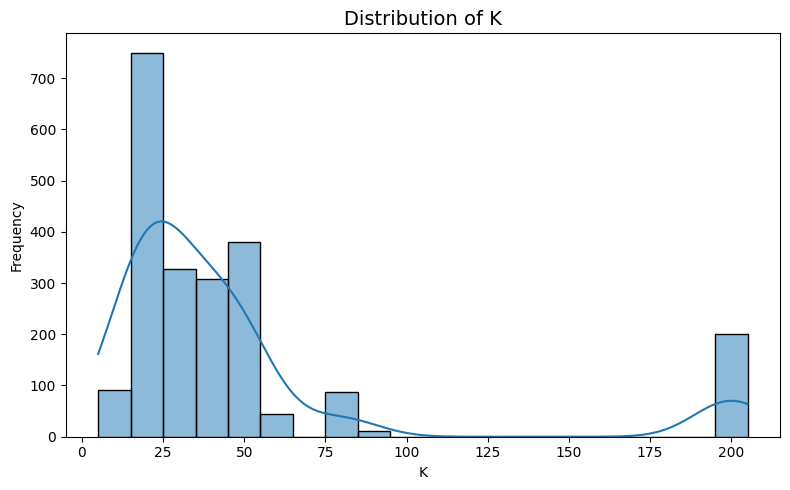


--------------------------------------------------------------------------------



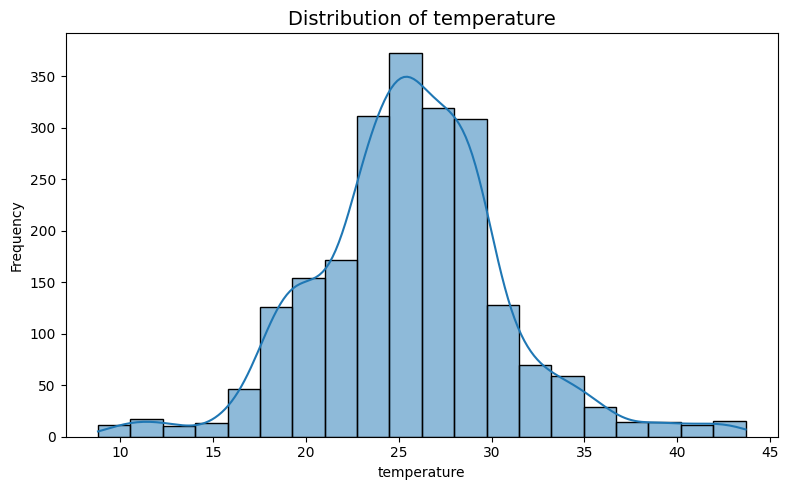


--------------------------------------------------------------------------------



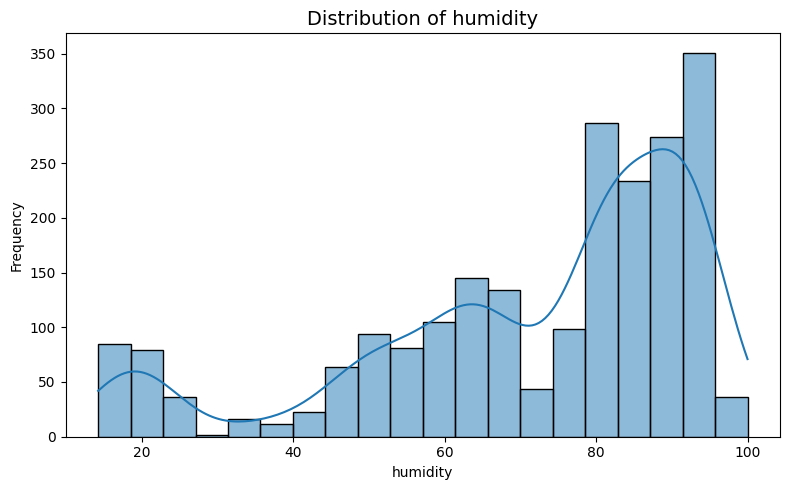


--------------------------------------------------------------------------------



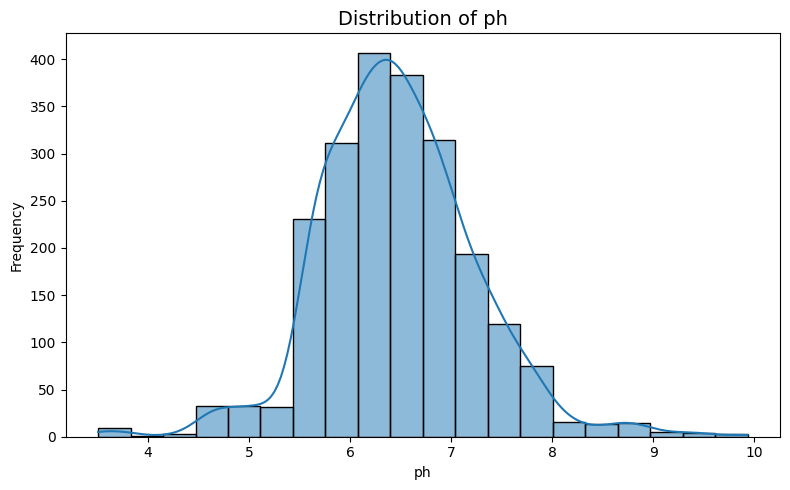


--------------------------------------------------------------------------------



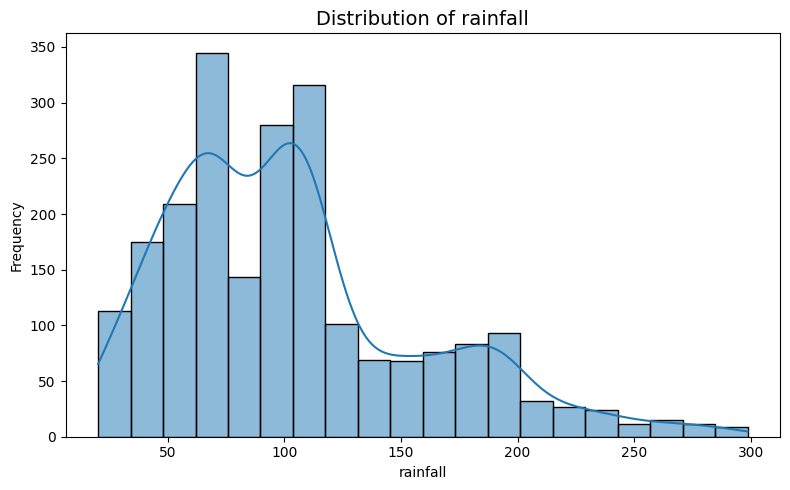


--------------------------------------------------------------------------------



In [20]:
features = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]

for col in features:
    plt.figure(figsize=(8, 5))

    sns.histplot(df[col], kde=True, bins=20)

    plt.title(f"Distribution of {col}", fontsize=14)
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

    print("\n" + "-"*80 + "\n")

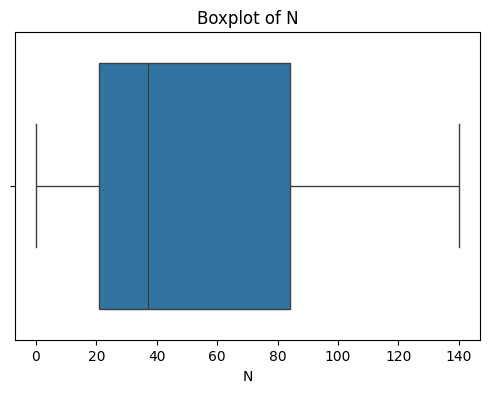

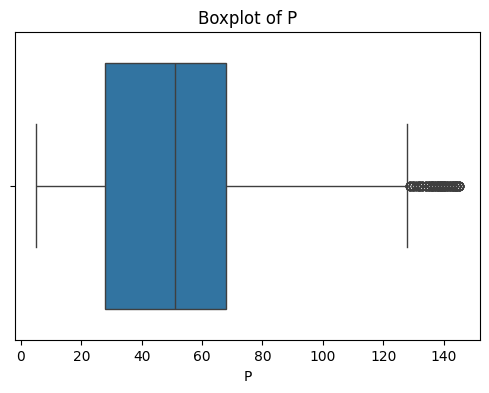

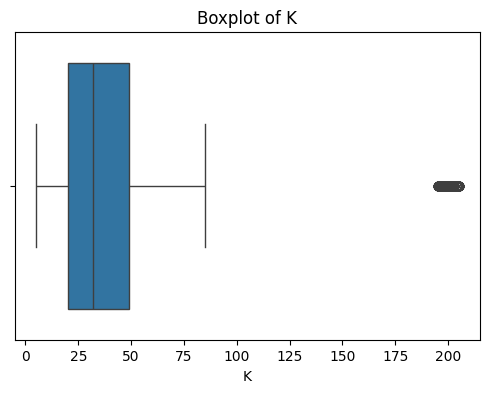

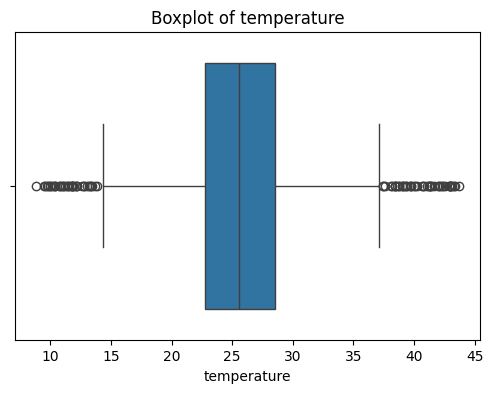

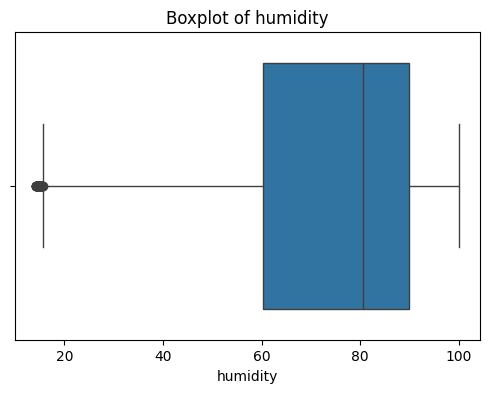

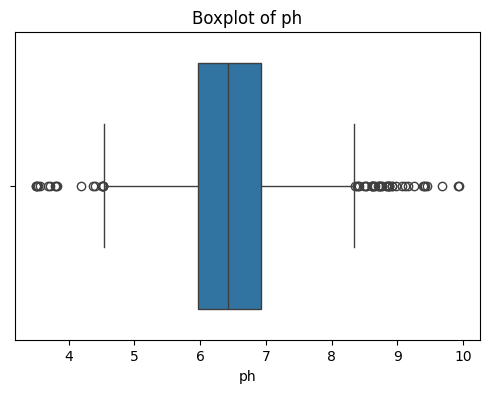

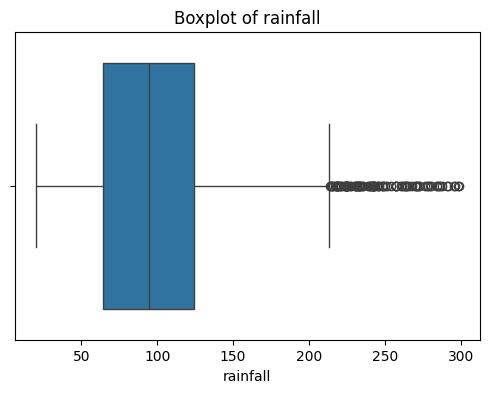

In [21]:
for col in features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [22]:
# conclusion : it shows potassium,phosphorus, temperature,humidity and ph shows ouliers but in
# agriculture datasets, extreme values are not always wrong. They may represent actual crop requirements.so we ignore this outlier part

# Bivariate Analysis

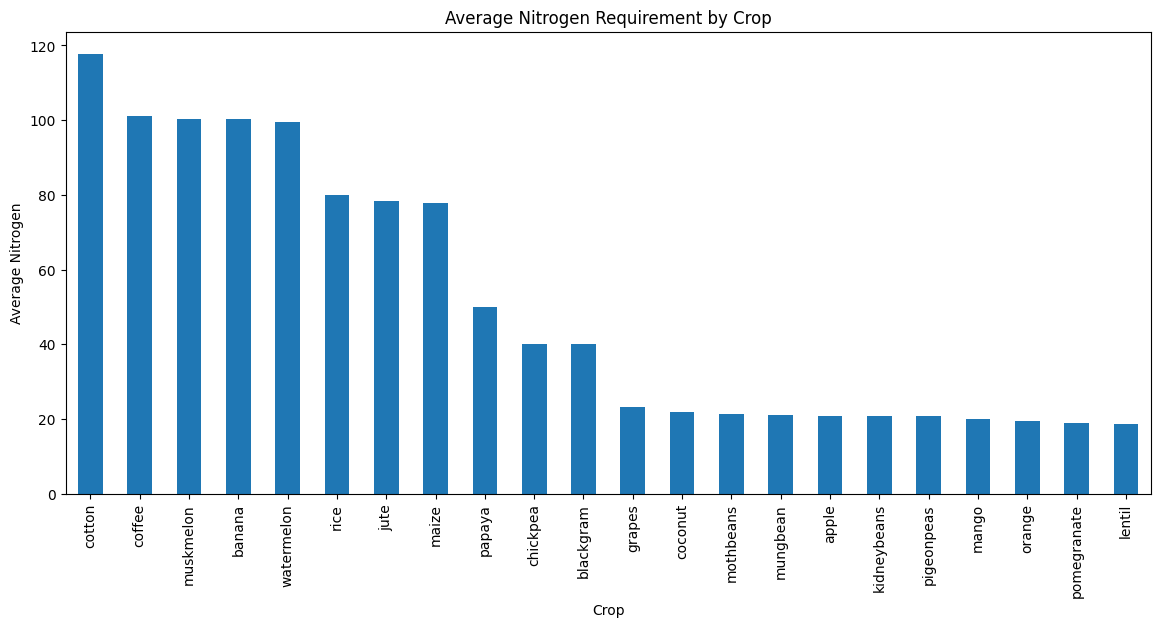

In [27]:
crop_n = df.groupby("label")["N"].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
crop_n.plot(kind="bar")
plt.title("Average Nitrogen Requirement by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Nitrogen")
plt.xticks(rotation=90)
plt.show()

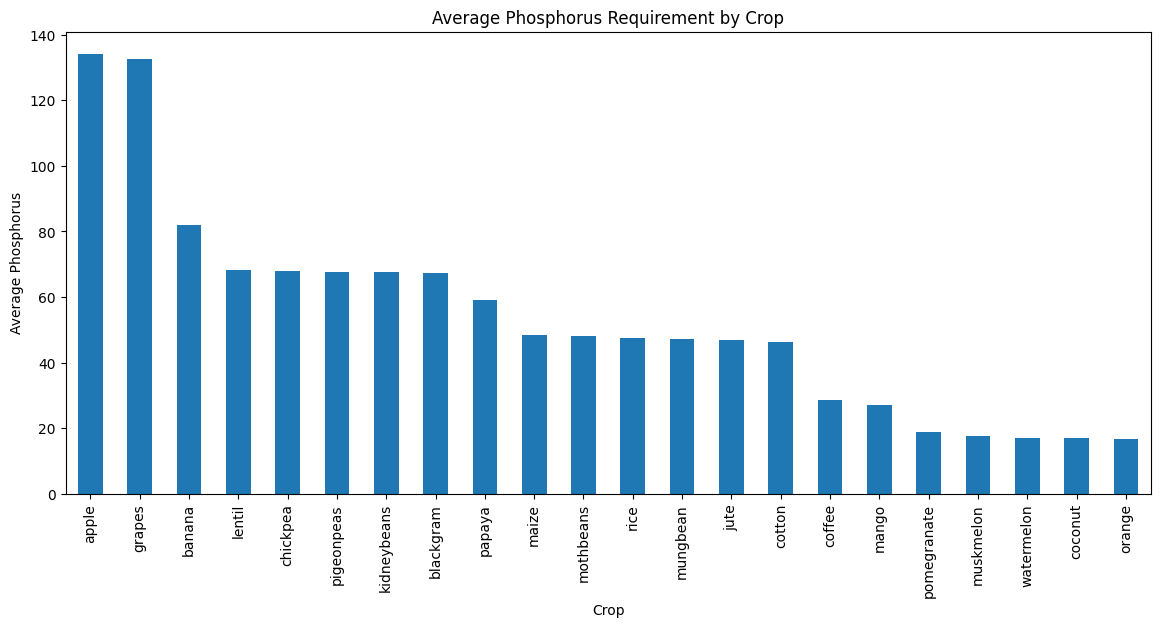

In [29]:
crop_p = df.groupby("label")["P"].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
crop_p.plot(kind="bar")
plt.title("Average Phosphorus Requirement by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Phosphorus")
plt.xticks(rotation=90)
plt.show()

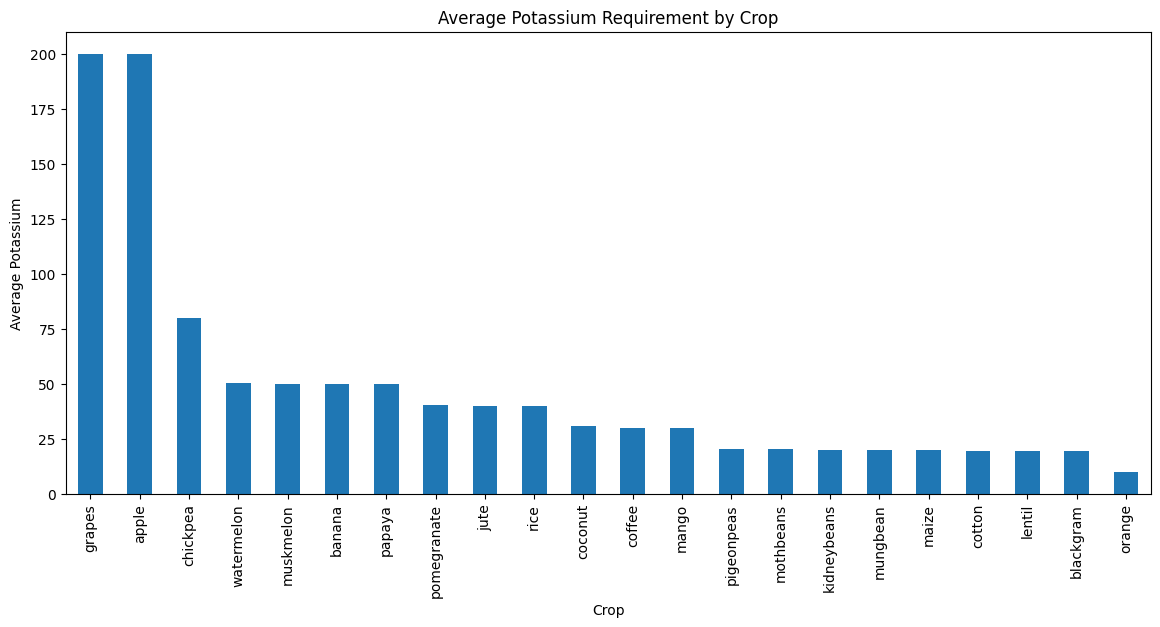

In [30]:
crop_k = df.groupby("label")["K"].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
crop_k.plot(kind="bar")
plt.title("Average Potassium Requirement by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Potassium")
plt.xticks(rotation=90)
plt.show()

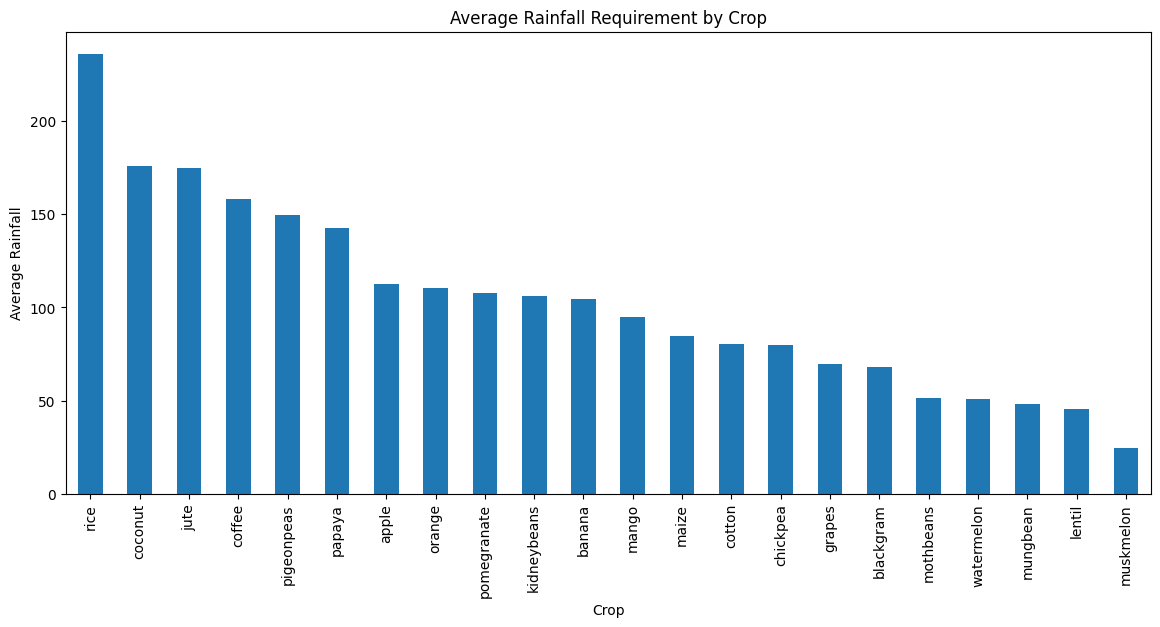

In [31]:
crop_rainfall = df.groupby("label")["rainfall"].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
crop_rainfall.plot(kind="bar")
plt.title("Average Rainfall Requirement by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Rainfall")
plt.xticks(rotation=90)
plt.show()

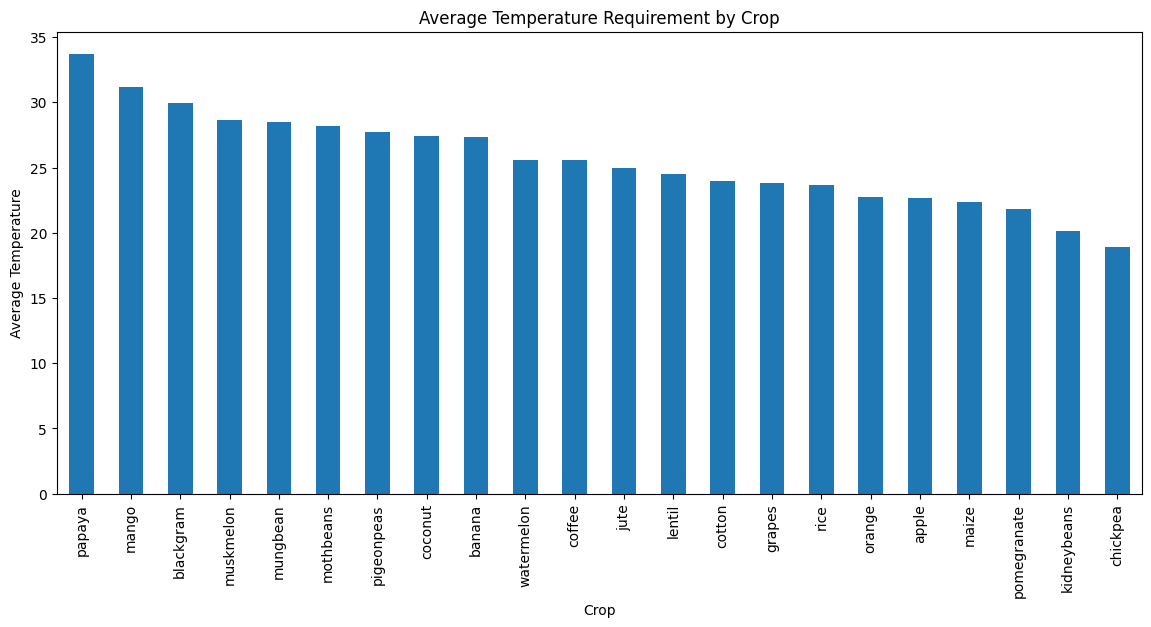

In [33]:
crop_temp = df.groupby("label")["temperature"].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
crop_temp.plot(kind="bar")
plt.title("Average Temperature Requirement by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Temperature")
plt.xticks(rotation=90)
plt.show()

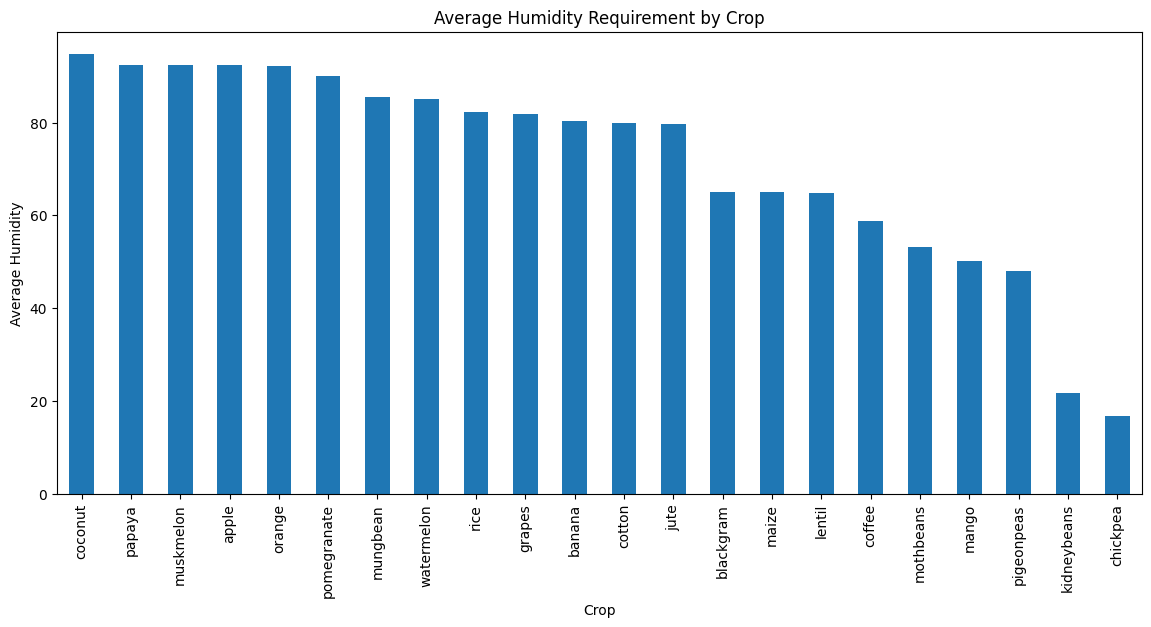

In [34]:
crop_humidity = df.groupby("label")["humidity"].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
crop_humidity.plot(kind="bar")
plt.title("Average Humidity Requirement by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Humidity")
plt.xticks(rotation=90)
plt.show()

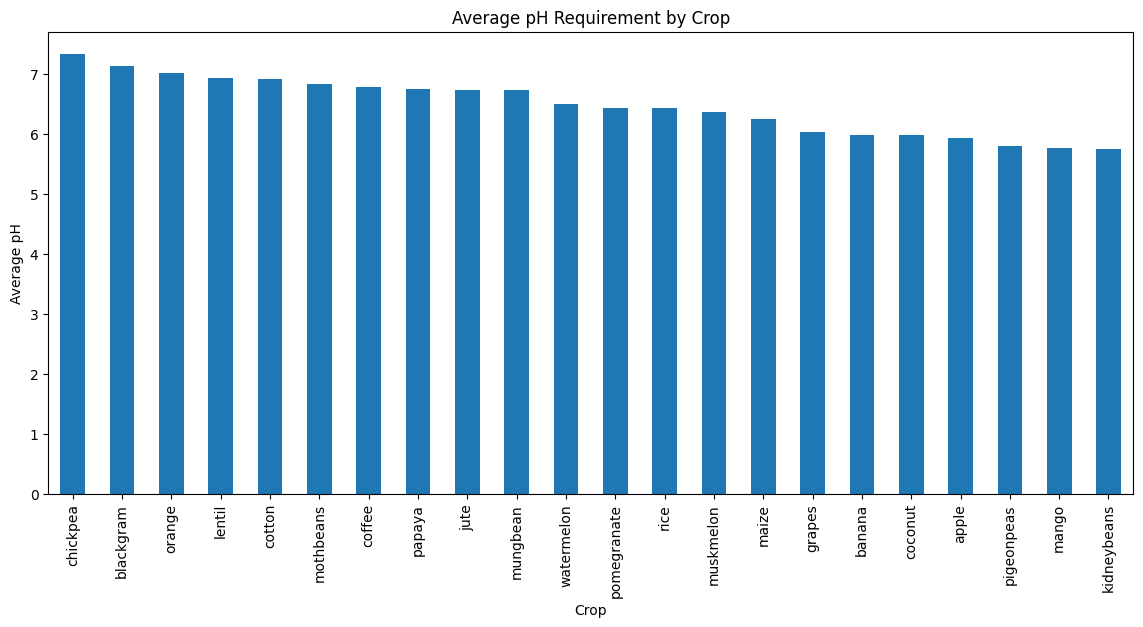

In [35]:
crop_ph = df.groupby("label")["ph"].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
crop_ph.plot(kind="bar")
plt.title("Average pH Requirement by Crop")
plt.xlabel("Crop")
plt.ylabel("Average pH")
plt.xticks(rotation=90)
plt.show()

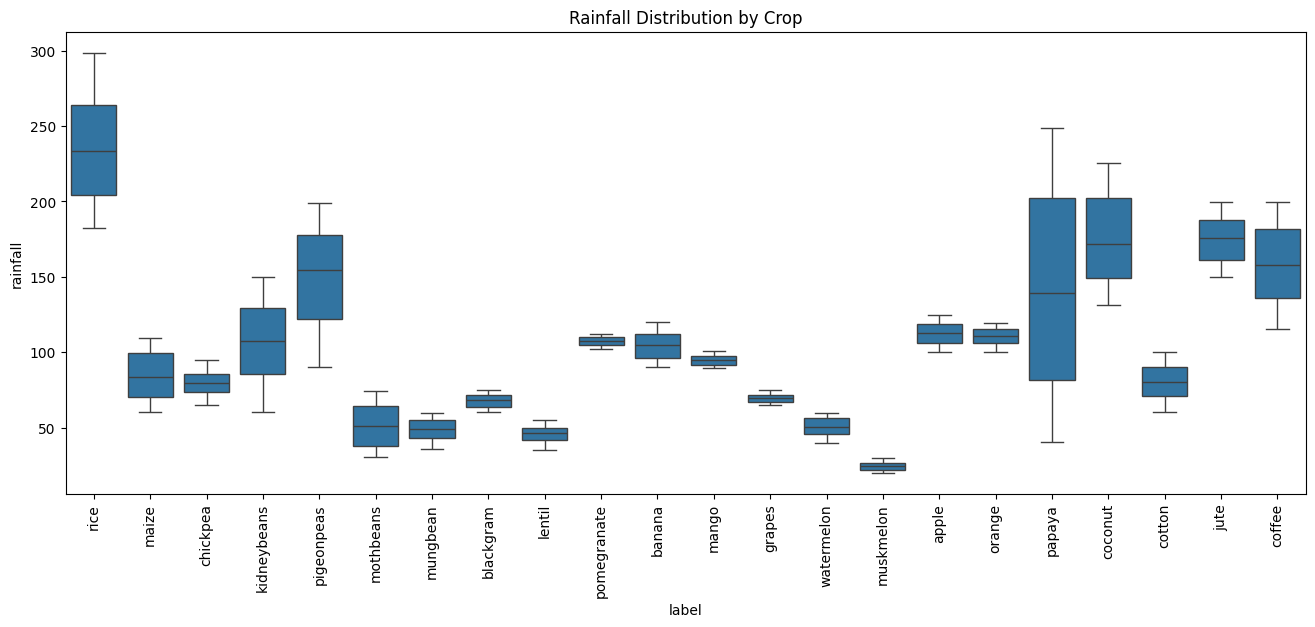

In [36]:
plt.figure(figsize=(16, 6))
sns.boxplot(x="label", y="rainfall", data=df)
plt.xticks(rotation=90)
plt.title("Rainfall Distribution by Crop")
plt.show()

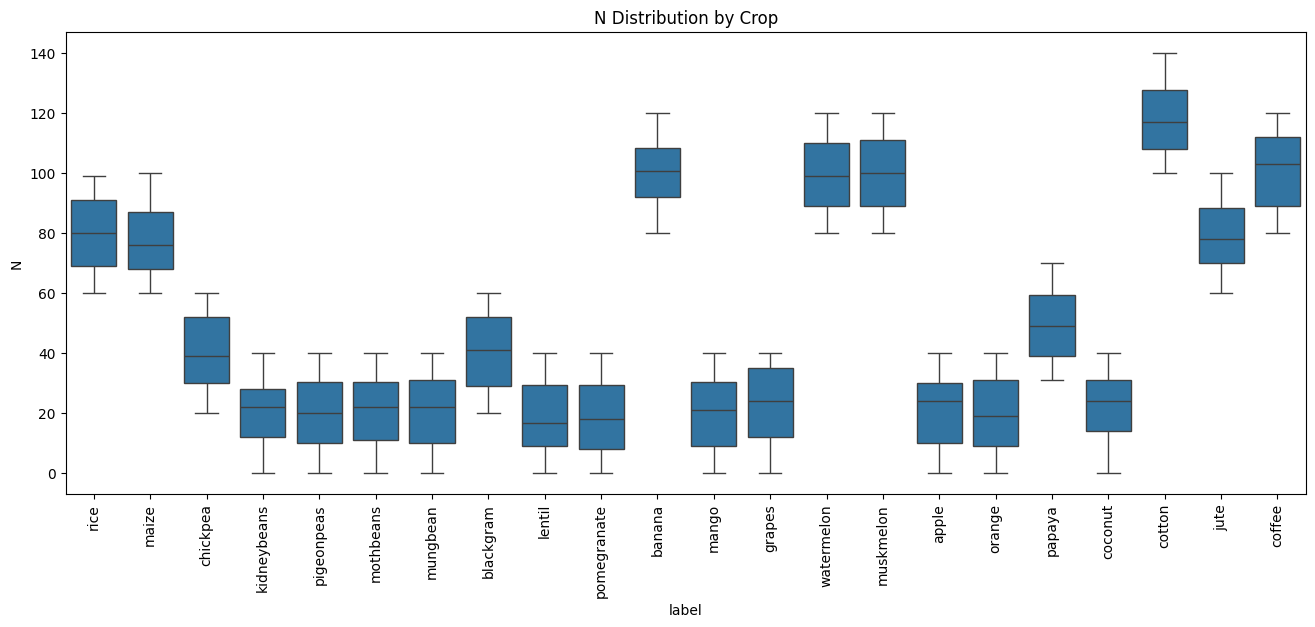

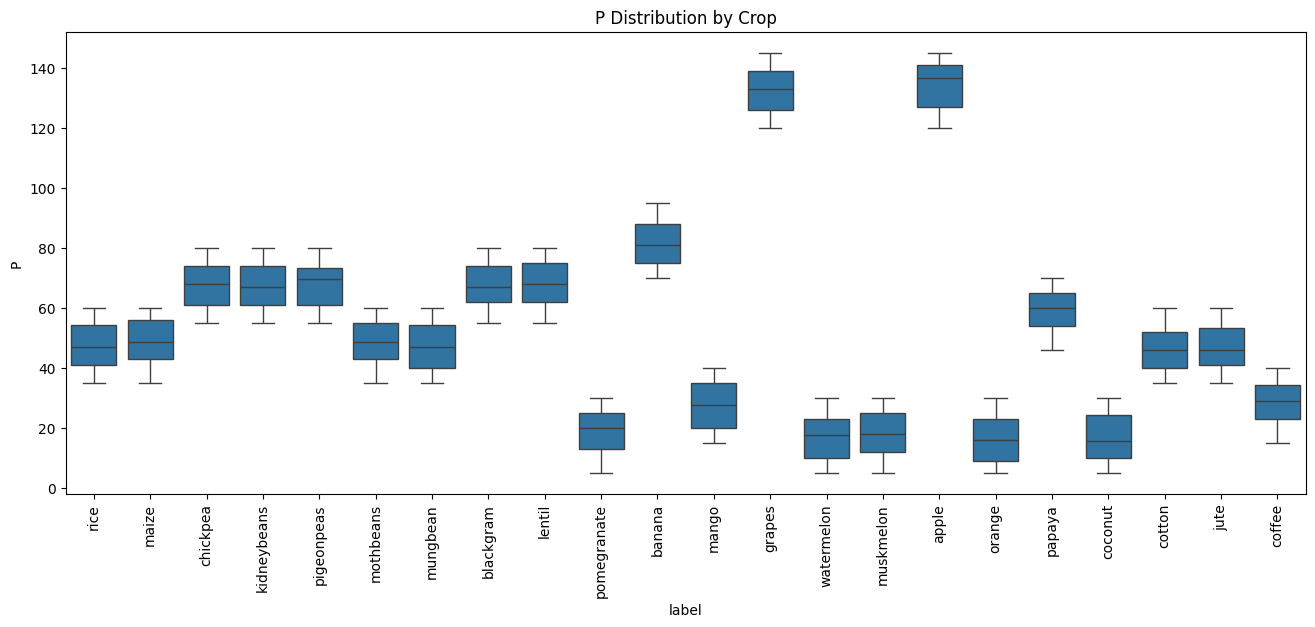

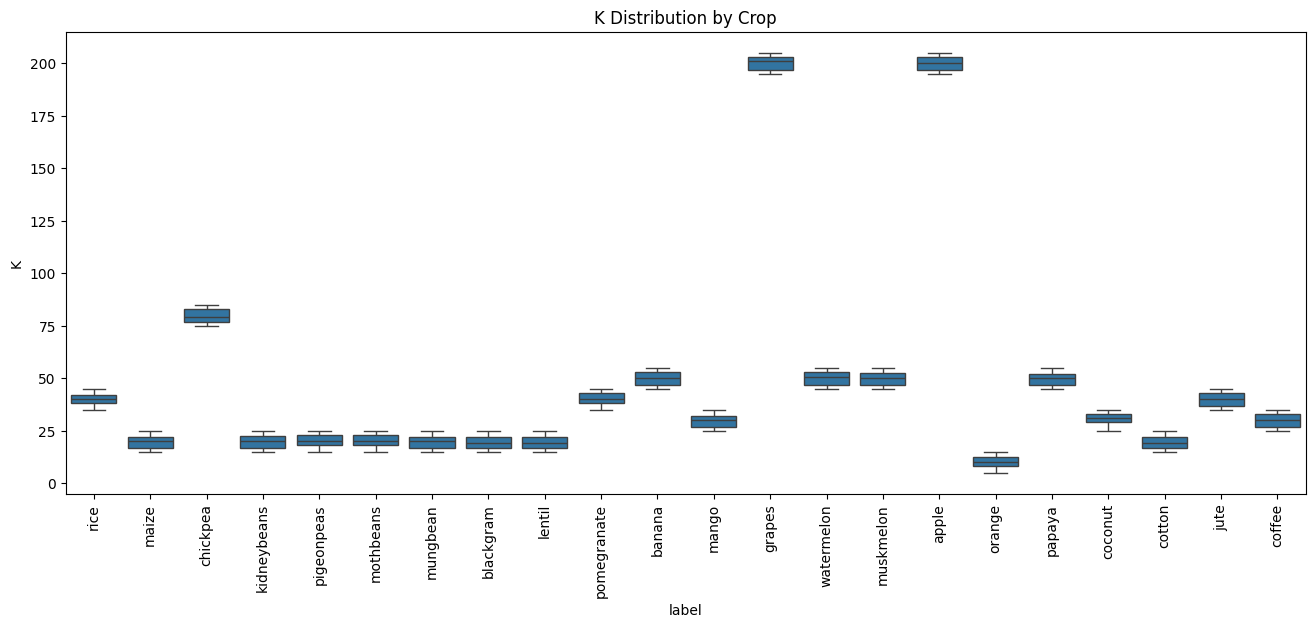

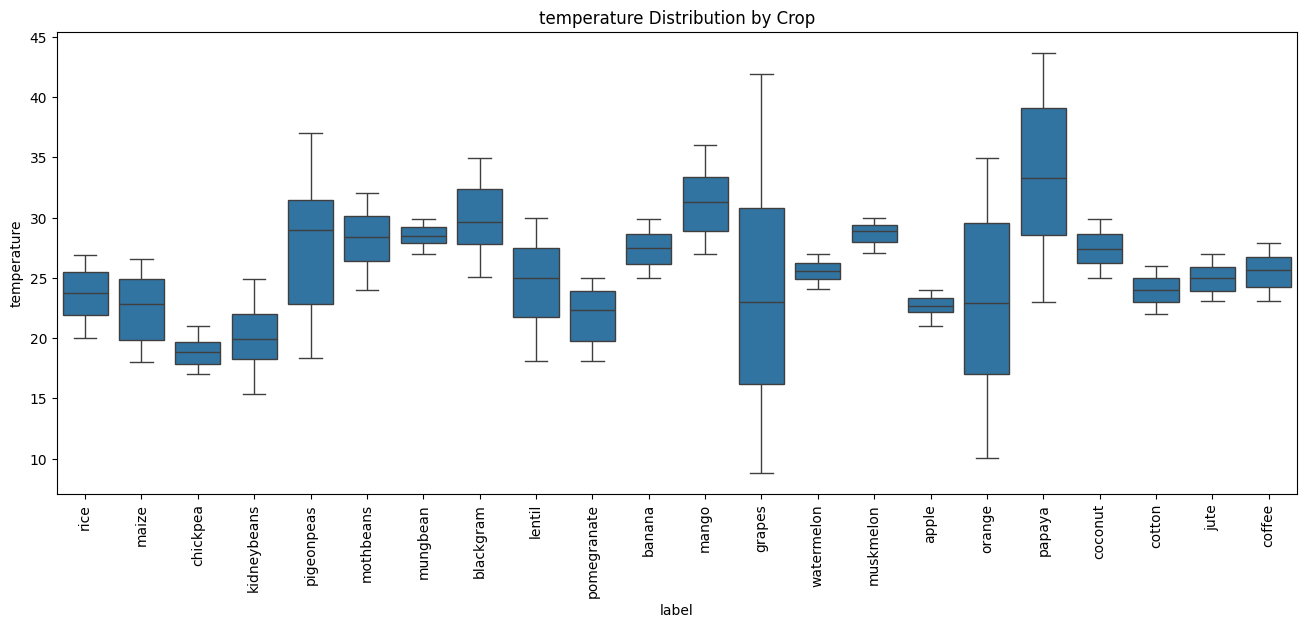

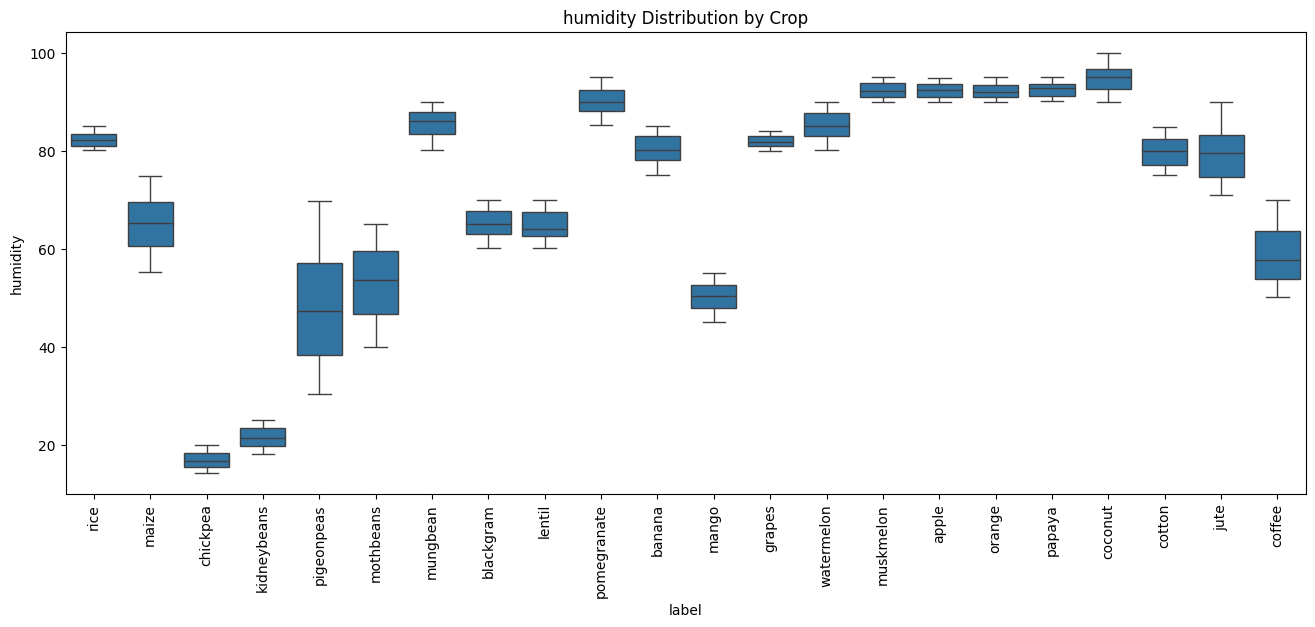

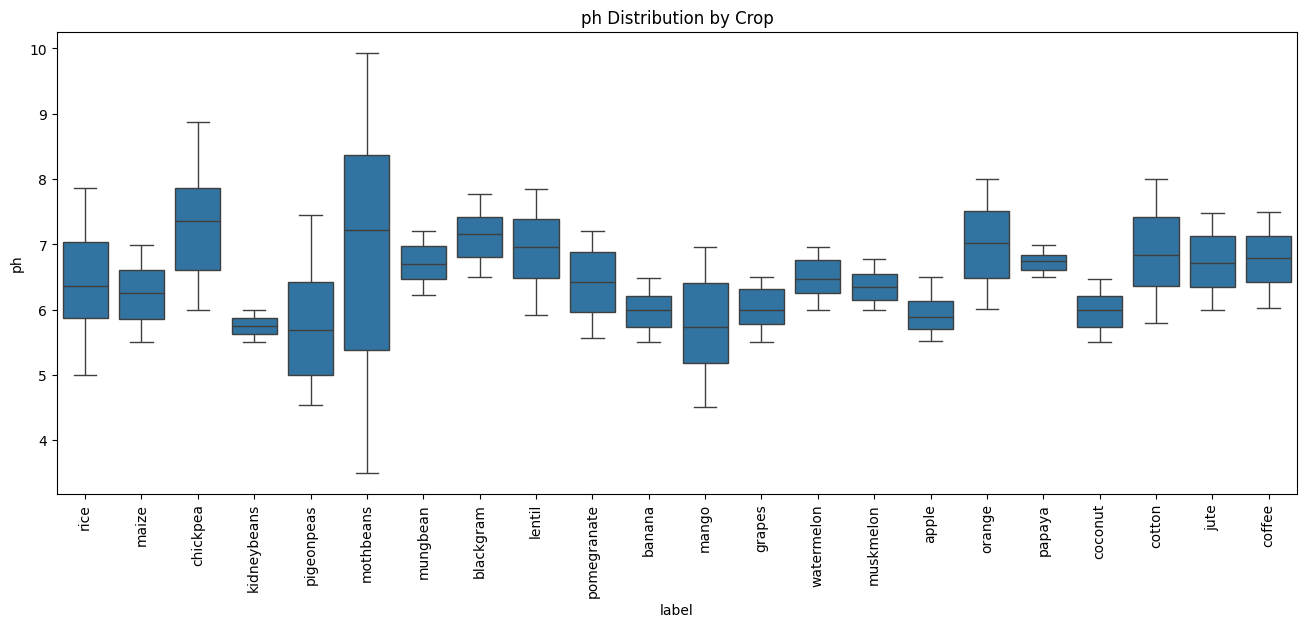

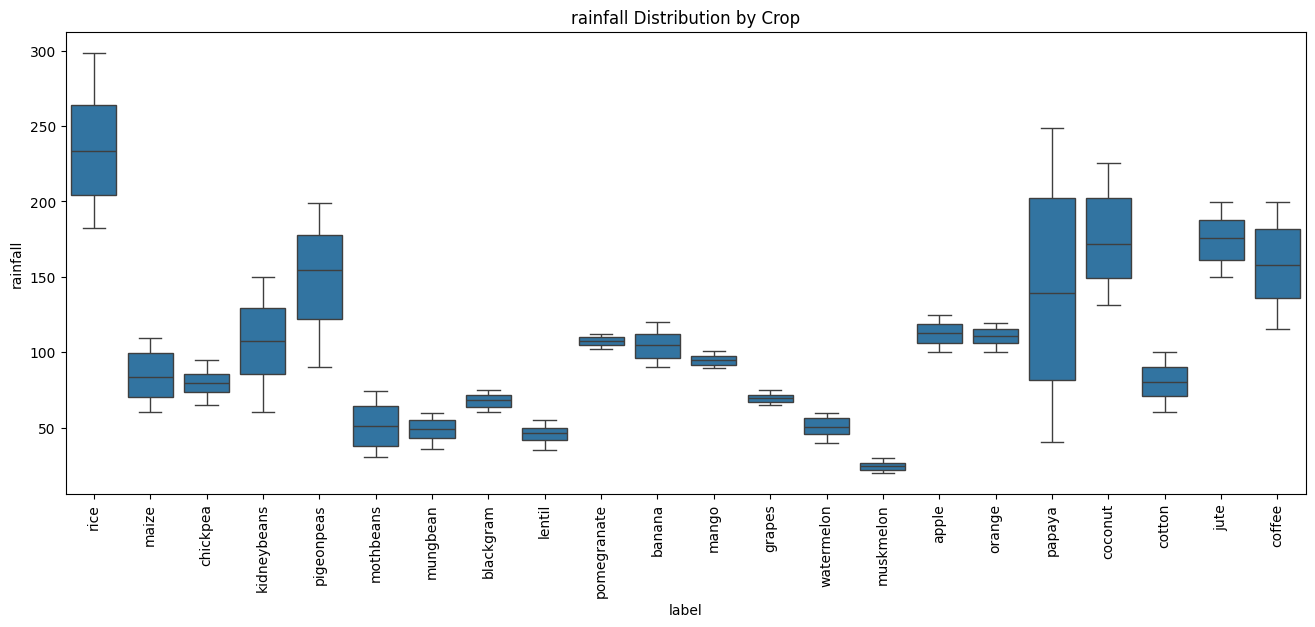

In [37]:
features = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]

for col in features:
    plt.figure(figsize=(16, 6))
    sns.boxplot(x="label", y=col, data=df)
    plt.xticks(rotation=90)
    plt.title(f"{col} Distribution by Crop")
    plt.show()

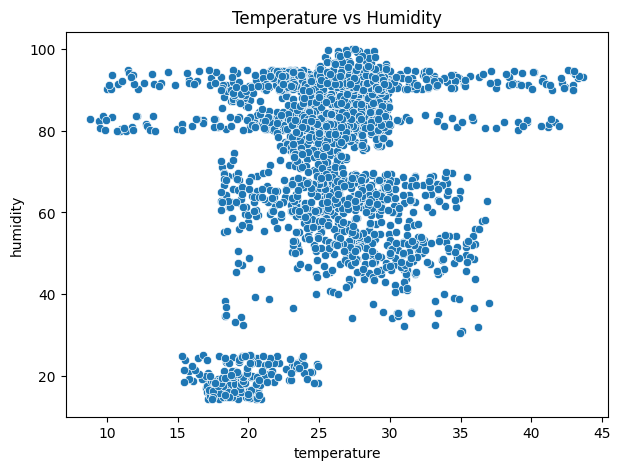

In [40]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x="temperature", y="humidity", data=df)
plt.title("Temperature vs Humidity")
plt.show()

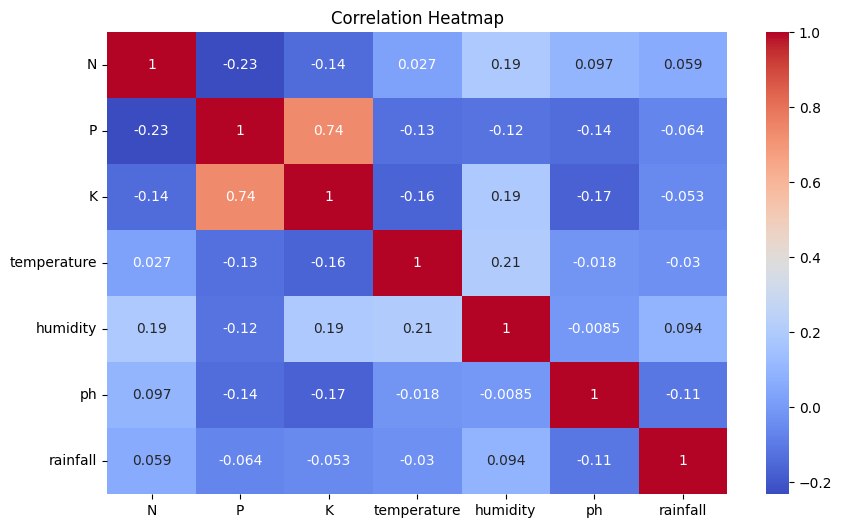

In [41]:
corr = df.drop("label", axis=1).corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Data Preprocessiing

In [42]:
X = df.drop("label", axis=1)
y = df["label"]

In [43]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [44]:
y_encoded

array([20, 20, 20, ...,  5,  5,  5], shape=(2200,))

In [45]:
# Show class-code mapping
class_mapping = pd.DataFrame({
    "Crop_Label": label_encoder.classes_,
    "Encoded_Value": range(len(label_encoder.classes_))
})

class_mapping

,Crop_Label,Encoded_Value
0,apple,0
1,banana,1
2,blackgram,2
3,chickpea,3
4,coconut,4
5,coffee,5
6,cotton,6
7,grapes,7
8,jute,8
9,kidneybeans,9


In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [47]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [48]:
X_train_scaled

array([[-1.37162846, -1.07290957, -0.67351002, ...,  0.92439516,
         0.93754456,  0.1994396 ],
       [-1.12741063,  2.08451298,  3.01526081, ...,  0.42661263,
        -1.15384595, -0.64367687],
       [-1.07314   ,  0.53616154, -0.47624954, ..., -2.18629069,
        -1.10745175,  0.69400094],
       ...,
       [ 0.8534673 , -0.1621146 , -0.23953698, ...,  0.46475923,
        -0.15548263,  1.63323326],
       [ 1.07054981, -0.10139494, -0.0817286 , ...,  0.09292232,
        -0.28148439,  1.23724576],
       [-1.34449314,  2.3881113 ,  2.99553476, ...,  0.51745   ,
        -1.08941335, -0.67077084]], shape=(1760, 7))

In [50]:
X_test_scaled

array([[-1.01886937, -0.92111041, -0.83131839, ...,  0.84613888,
         1.13848097, -0.01374611],
       [ 1.28763233,  0.77904019,  0.03662768, ...,  0.58616143,
        -0.04841589, -0.2253062 ],
       [ 2.42731552, -0.46571293, -0.65378397, ...,  0.20050841,
        -0.57771584, -0.60999985],
       ...,
       [ 0.52784353, -0.46571293, -0.25926302, ...,  0.35250427,
         0.68989384,  1.10624666],
       [-0.80178686,  2.44883096,  3.03498685, ...,  0.38629579,
        -0.06182135, -0.69398814],
       [-0.39475715,  0.41472221, -0.4565235 , ..., -1.56631835,
        -0.0712168 ,  0.59286777]], shape=(440, 7))

# Model Training

In [57]:
# Logistic Regression model
lr = LogisticRegression(max_iter=5000)

# Train model
lr.fit(X_train_scaled, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [58]:
from sklearn.model_selection import cross_val_score


# Cross-validation on training data
lr_cv_scores = cross_val_score(
    lr,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Logistic Regression CV Scores:", lr_cv_scores)
print("Logistic Regression Mean CV Accuracy:", lr_cv_scores.mean())
print("Logistic Regression CV Std:", lr_cv_scores.std())

# Training prediction
y_train_pred_lr = lr.predict(X_train_scaled)

# Training accuracy
lr_train_accuracy = accuracy_score(y_train, y_train_pred_lr)

# Test prediction
y_pred_lr = lr.predict(X_test_scaled)

# Test accuracy
lr_test_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Training Accuracy:", lr_train_accuracy)
print("Logistic Regression Test Accuracy:", lr_test_accuracy)

Logistic Regression CV Scores: [0.97443182 0.94886364 0.98295455 0.96590909 0.96590909]
Logistic Regression Mean CV Accuracy: 0.9676136363636363
Logistic Regression CV Std: 0.011306675421666133
Logistic Regression Training Accuracy: 0.9738636363636364
Logistic Regression Test Accuracy: 0.9727272727272728


In [61]:
svm = SVC(kernel="rbf", probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [62]:
svm_cv_scores = cross_val_score(
    svm,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("SVM CV Scores:", svm_cv_scores)
print("SVM Mean CV Accuracy:", svm_cv_scores.mean())
print("SVM CV Std:", svm_cv_scores.std())

y_train_pred_svm = svm.predict(X_train_scaled)

svm_train_accuracy = accuracy_score(y_train, y_train_pred_svm)

y_pred_svm = svm.predict(X_test_scaled)

svm_test_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Training Accuracy:", svm_train_accuracy)
print("SVM Test Accuracy:", svm_test_accuracy)

SVM CV Scores: [0.97727273 0.96590909 0.97727273 0.98863636 0.97159091]
SVM Mean CV Accuracy: 0.9761363636363637
SVM CV Std: 0.00753778361444409
SVM Training Accuracy: 0.9857954545454546
SVM Test Accuracy: 0.9840909090909091


In [59]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [60]:
knn_cv_scores = cross_val_score(
    knn,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("KNN CV Scores:", knn_cv_scores)
print("KNN Mean CV Accuracy:", knn_cv_scores.mean())
print("KNN CV Std:", knn_cv_scores.std())

y_train_pred_knn = knn.predict(X_train_scaled)

knn_train_accuracy = accuracy_score(y_train, y_train_pred_knn)

y_pred_knn = knn.predict(X_test_scaled)

knn_test_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Training Accuracy:", knn_train_accuracy)
print("KNN Test Accuracy:", knn_test_accuracy)


KNN CV Scores: [0.96590909 0.95170455 0.97443182 0.96590909 0.96875   ]
KNN Mean CV Accuracy: 0.965340909090909
KNN CV Std: 0.0074948329308369135
KNN Training Accuracy: 0.9846590909090909
KNN Test Accuracy: 0.9795454545454545


In [63]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [64]:
dt_cv_scores = cross_val_score(
    dt,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Decision Tree CV Scores:", dt_cv_scores)
print("Decision Tree Mean CV Accuracy:", dt_cv_scores.mean())
print("Decision Tree CV Std:", dt_cv_scores.std())


y_train_pred_dt = dt.predict(X_train_scaled)

dt_train_accuracy = accuracy_score(y_train, y_train_pred_dt)

y_pred_dt = dt.predict(X_test_scaled)

dt_test_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Training Accuracy:", dt_train_accuracy)
print("Decision Tree Test Accuracy:", dt_test_accuracy)

Decision Tree CV Scores: [0.97159091 0.98863636 0.98295455 0.99147727 0.98863636]
Decision Tree Mean CV Accuracy: 0.9846590909090909
Decision Tree CV Std: 0.007096588634543646
Decision Tree Training Accuracy: 1.0
Decision Tree Test Accuracy: 0.9795454545454545


In [65]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [66]:
rf_cv_scores = cross_val_score(
    rf,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Random Forest CV Scores:", rf_cv_scores)
print("Random Forest Mean CV Accuracy:", rf_cv_scores.mean())
print("Random Forest CV Std:", rf_cv_scores.std())


y_train_pred_rf = rf.predict(X_train_scaled)


rf_train_accuracy = accuracy_score(y_train, y_train_pred_rf)


y_pred_rf = rf.predict(X_test_scaled)


rf_test_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Training Accuracy:", rf_train_accuracy)
print("Random Forest Test Accuracy:", rf_test_accuracy)

Random Forest CV Scores: [0.99147727 0.99431818 0.99715909 0.99715909 0.98579545]
Random Forest Mean CV Accuracy: 0.9931818181818182
Random Forest CV Std: 0.004251883394061294
Random Forest Training Accuracy: 1.0
Random Forest Test Accuracy: 0.9954545454545455


In [69]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X_train_scaled, y_train)

,priors,None
,var_smoothing,1e-09


In [70]:
nb_cv_scores = cross_val_score(
    nb,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Naive Bayes CV Scores:", nb_cv_scores)
print("Naive Bayes Mean CV Accuracy:", nb_cv_scores.mean())
print("Naive Bayes CV Std:", nb_cv_scores.std())



y_train_pred_nb = nb.predict(X_train_scaled)


nb_train_accuracy = accuracy_score(y_train, y_train_pred_nb)


y_pred_nb = nb.predict(X_test_scaled)


nb_test_accuracy = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Training Accuracy:", nb_train_accuracy)
print("Naive Bayes Test Accuracy:", nb_test_accuracy)

Naive Bayes CV Scores: [0.99715909 0.99147727 1.         0.99715909 0.98579545]
Naive Bayes Mean CV Accuracy: 0.9943181818181819
Naive Bayes CV Std: 0.005081972676135881
Naive Bayes Training Accuracy: 0.9948863636363636
Naive Bayes Test Accuracy: 0.9954545454545455


In [71]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVM",
        "KNN",
        "Decision Tree",
        "Random Forest",
        "Naive Bayes"
    ],
    "Training Accuracy": [
        lr_train_accuracy,
        svm_train_accuracy,
        knn_train_accuracy,
        dt_train_accuracy,
        rf_train_accuracy,
        nb_train_accuracy
    ],
    "Mean CV Accuracy": [
        lr_cv_scores.mean(),
        svm_cv_scores.mean(),
        knn_cv_scores.mean(),
        dt_cv_scores.mean(),
        rf_cv_scores.mean(),
        nb_cv_scores.mean()
    ],
    "CV Standard Deviation": [
        lr_cv_scores.std(),
        svm_cv_scores.std(),
        knn_cv_scores.std(),
        dt_cv_scores.std(),
        rf_cv_scores.std(),
        nb_cv_scores.std()
    ],
    "Test Accuracy": [
        lr_test_accuracy,
        svm_test_accuracy,
        knn_test_accuracy,
        dt_test_accuracy,
        rf_test_accuracy,
        nb_test_accuracy
    ]
})

model_comparison = model_comparison.sort_values(
    by="Test Accuracy",
    ascending=False
)

model_comparison

,Model,Training Accuracy,Mean CV Accuracy,CV Standard Deviation,Test Accuracy
4,Random Forest,1.000000,0.993182,0.004252,0.995455
5,Naive Bayes,0.994886,0.994318,0.005082,0.995455
1,SVM,0.985795,0.976136,0.007538,0.984091
3,Decision Tree,1.000000,0.984659,0.007097,0.979545
2,KNN,0.984659,0.965341,0.007495,0.979545
0,Logistic Regression,0.973864,0.967614,0.011307,0.972727


# Model Evaluation 

In [73]:
from sklearn.metrics import classification_report

print("Random Forest Classification Report:")

print(classification_report(
    y_test,
    y_pred_rf,
    target_names=label_encoder.classes_
))

Random Forest Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00 

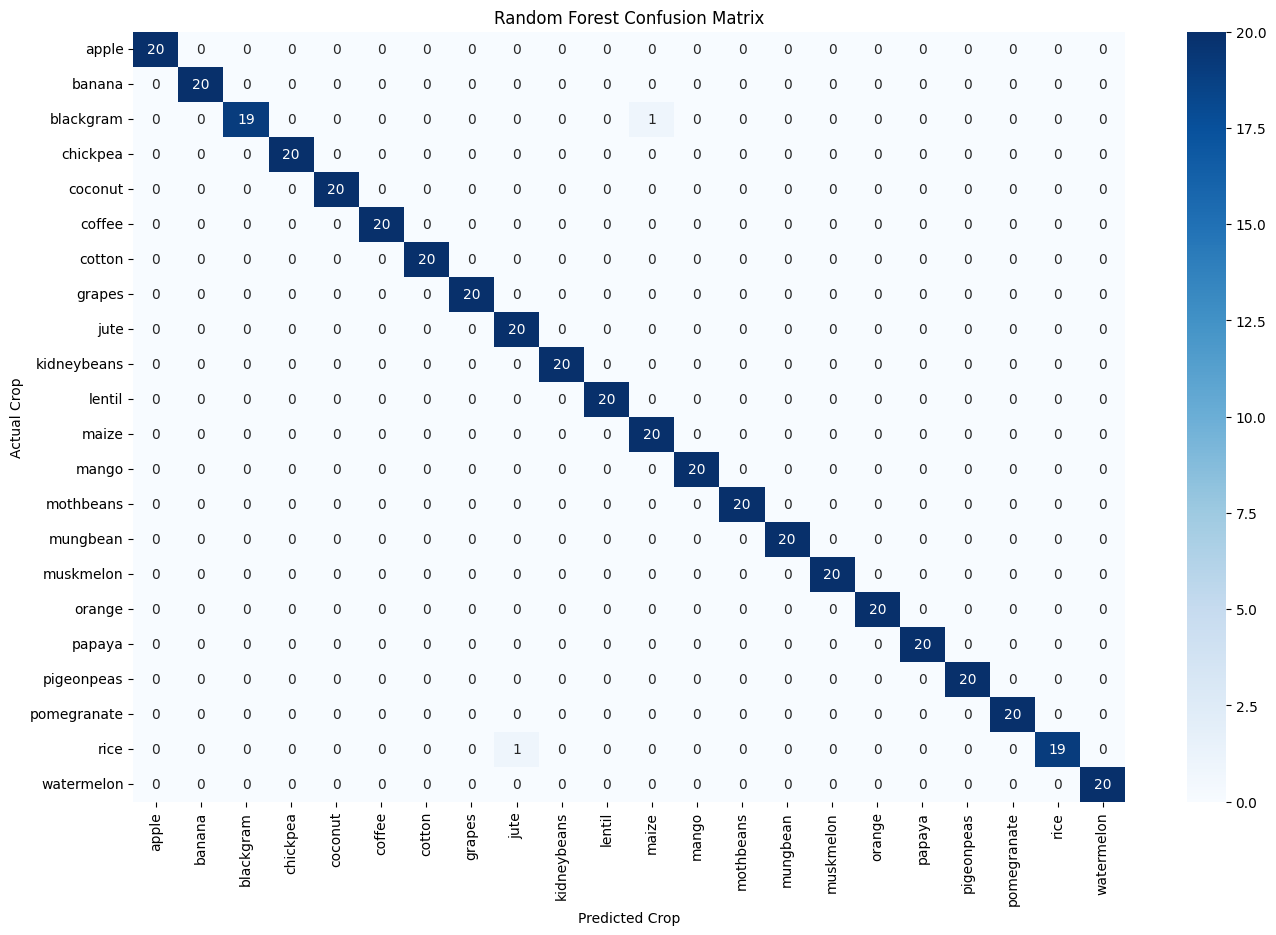

In [75]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(16, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Crop")
plt.ylabel("Actual Crop")
plt.title("Random Forest Confusion Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

In [77]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(feature_importance)

       Feature  Importance
6     rainfall    0.230184
4     humidity    0.224227
2            K    0.175393
1            P    0.150850
0            N    0.096363
3  temperature    0.072375
5           ph    0.050608


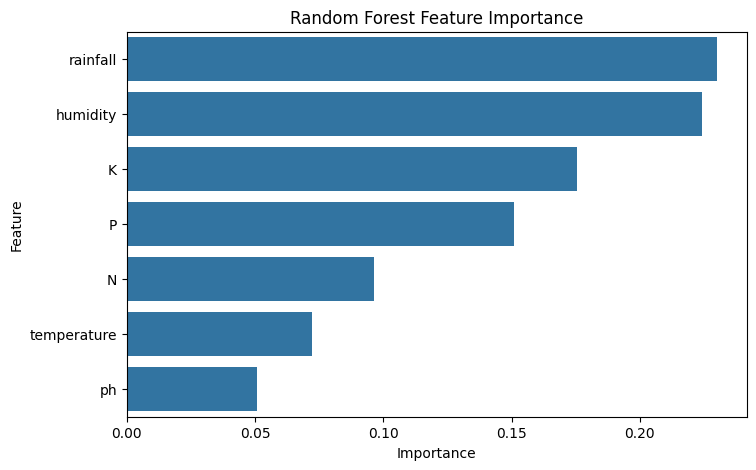

In [78]:
plt.figure(figsize=(8, 5))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [81]:
import pandas as pd

sample_input = pd.DataFrame([{
    "N": 90,
    "P": 42,
    "K": 43,
    "temperature": 20.8,
    "humidity": 82.0,
    "ph": 6.5,
    "rainfall": 202.0
}])

sample_input_scaled = scaler.transform(sample_input)

sample_prediction = rf.predict(sample_input_scaled)

sample_crop = label_encoder.inverse_transform(sample_prediction)

print("Recommended Crop:", sample_crop[0])

Recommended Crop: rice


# Model Save

In [82]:
import pickle

with open("crop_model.pkl", "wb") as f:
    pickle.dump(rf, f)

with open("crop_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("crop_label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

print("Model, scaler, and label encoder saved successfully!")

Model, scaler, and label encoder saved successfully!
